In [1]:
import sys
from pathlib import Path
import pandas as pd

# --- Step 1: Ingest All Raw DVS Files ---
# This ensures the notebook can find the 'src' directory
# Assumes the notebook is in 'notebooks/' and src is a sibling directory
# /home/mouneer_alrayes/graphage13-sorption/
#   ├── notebooks/
#   └── src/
#
# Get the project root directory
project_root = Path.cwd().parent 
# Add the 'src' directory to the Python path
sys.path.append(str(project_root / 'src'))

# Define the data directory path
DATA_DIR = project_root / 'data' / 'raw'

# --- Import Your Custom Ingestion Logic ---
# Now you can import from ingestion.py
from ingestion import ingest_sorption_data

# --- Run the Ingestion Pipeline ---
# This one function call processes all .xlsx files in your data directory
all_experiments = ingest_sorption_data(DATA_DIR)

# --- Explore the Ingested Data ---
# Separate successful from failed ingestions
successful_ingestions = []
failed_files = []

for data_package, meta in all_experiments:
    # Check if the parsing function returned an error
    if 'error' in meta:
        failed_files.append(meta.get('source_file', 'Unknown File') + f": {meta['error']}")
    else:
        # 1. Unpack the kinetic time-series DataFrame from the data package dictionary
        df = data_package['kinetic_data']
        
        # Add sample name to the dataframe for successful ingestions
        sample_name = meta.get('sample_name', meta.get('source_file', 'unknown_sample'))
        df['sample_name'] = sample_name
        successful_ingestions.append(df)

# --- Report on Ingestion Status ---
print(f"--- Ingestion Report ---")
print(f"Successfully parsed: {len(successful_ingestions)} file(s)")
print(f"Failed to parse:   {len(failed_files)} file(s)")

if failed_files:
    print("\n--- Failure Details ---")
    for reason in failed_files:
        print(f"- {reason}")

# --- Process and Display Successfully Ingested Data ---
if successful_ingestions:
    # Concatenate all individual dataframes into a single one
    master_df = pd.concat(successful_ingestions, ignore_index=True)
    
    print("\n--- Master DataFrame Head (Combined from all files) ---")
    display(master_df.head())
    
    print("\n--- Master DataFrame Info ---")
    master_df.info()
else:
    print("\nNo data was successfully ingested to create a master DataFrame.")

2026-07-14 16:57:05,664 - INFO - Starting ingestion from directory: /home/mouneer_alrayes/graphage13-sorption/data/raw
2026-07-14 16:57:05,666 - INFO - Processing file: 4M13 sample 3 17-05-24-0-90-0 0.002% stop 30min-12hr-2024-05-17 14-25-33.xlsx
2026-07-14 16:57:08,032 - INFO - Successfully parsed 2415 kinetic points and 31 isotherm points.
2026-07-14 16:57:08,033 - INFO - Processing file: GPA 0.002% 0-90-0 x 3.xlsx
2026-07-14 16:57:21,197 - INFO - Successfully parsed 14970 kinetic points and 50 isotherm points.
2026-07-14 16:57:21,199 - INFO - Processing file: GPA 80_ sample 3-0-90-0 0.002_ stop 30min-12hr-2024-06-07 13-43-07.xlsx
2026-07-14 16:57:25,131 - INFO - Successfully parsed 4517 kinetic points and 31 isotherm points.
2026-07-14 16:57:25,132 - INFO - Processing file: 0.25M13 sample 3-0-90-0 0.002% stop 30min-12hr-2024-05-31 15-04-20.xls
2026-07-14 16:57:26,251 - INFO - Successfully parsed 3391 kinetic points and 31 isotherm points.
2026-07-14 16:57:26,252 - INFO - Processing 

--- Ingestion Report ---
Successfully parsed: 5 file(s)
Failed to parse:   0 file(s)

--- Master DataFrame Head (Combined from all files) ---


,time_minutes_,mass_mg_,delta_mass_,dm_dt_minute_,target_incubator_temp_celsius_,measured_incubator_temp_celsius_,target_preheater_temp_celsius_,measured_preheater_temp_celsius_,sorption_temp_celsius_,target_partial_pressure_solvent_a_,...,unnamed_84,target_chiller_temp_celsius_,measured_chiller_temp_celsius_,measured_chiller_internal_temp_celsius_,chiller_state,gas_concentration_sensor_a_ppm_,gas_concentration_sensor_b_ppm_,sample_name,target_p_p0,dm_
0,0.00,3.7727,75.454,-394.5271,25,24.8,0,0,24.9,0.0,...,0,-10,0,0,Off,0,0,4M13 sample 3 17:05:24:0:90:0 0.002% stop 30mi...,NaN,NaN
1,1.00,3.7041,74.082,-0.4714,25,25.0,0,0,24.9,0.0,...,0,-10,0,0,Off,0,0,4M13 sample 3 17:05:24:0:90:0 0.002% stop 30mi...,NaN,NaN
2,2.01,3.6604,73.208,379.7382,25,25.0,0,0,25.0,0.0,...,0,-10,0,0,Off,0,0,4M13 sample 3 17:05:24:0:90:0 0.002% stop 30mi...,NaN,NaN
3,3.01,3.6357,72.714,709.7727,25,25.0,0,0,25.0,0.0,...,0,-10,0,0,Off,0,0,4M13 sample 3 17:05:24:0:90:0 0.002% stop 30mi...,NaN,NaN
4,4.01,3.6196,72.392,110.2624,25,25.0,0,0,25.0,0.0,...,0,-10,0,0,Off,0,0,4M13 sample 3 17:05:24:0:90:0 0.002% stop 30mi...,NaN,NaN



--- Master DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30076 entries, 0 to 30075
Data columns (total 94 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   time_minutes_                            30076 non-null  float64
 1   mass_mg_                                 30076 non-null  float64
 2   delta_mass_                              30076 non-null  float64
 3   dm_dt_minute_                            30076 non-null  float64
 4   target_incubator_temp_celsius_           30076 non-null  int64  
 5   measured_incubator_temp_celsius_         30076 non-null  float64
 6   target_preheater_temp_celsius_           30076 non-null  int64  
 7   measured_preheater_temp_celsius_         30076 non-null  int64  
 8   sorption_temp_celsius_                   30076 non-null  float64
 9   target_partial_pressure_solvent_a_       15106 non-null  float64
 10  measured_partia

In [2]:
# --- Step 2: Isolate Kinetic Modeling Essentials ---

# The DVS software exports the target RH staircase under different column
# names depending on which method file was used: 'target_p_p0' for the
# standard GPA run, 'target_partial_pressure_solvent_a_' for the other four.
# Both hold the exact same 0/10/20/.../90/.../0 staircase (verified: pure
# integer multiples of 10, no sensor noise) -- only one is populated per
# sample, the other is NaN. Coalesce them into one canonical 'target_rh'
# column before dropping the rest, so nothing downstream has to know which
# raw name a given file happened to use.
target_rh_aliases = [
    c for c in master_df.columns
    if c.startswith('target') and ('p_p0' in c or 'partial_pressure_solvent_a' in c)
]
print(f"Target RH column aliases found across raw files: {target_rh_aliases}")

master_df['target_rh'] = master_df[target_rh_aliases].bfill(axis=1).iloc[:, 0]
assert master_df['target_rh'].notna().all(), "Some rows have no target RH under any known alias -- check for a new column-naming variant."

# Define the precise column parameters needed for mass-uptake calculations
essential_columns = [
    'sample_name', 
    'time_minutes_', 
    'mass_mg_', 
    'delta_mass_', 
    'dm_dt_minute_', 
    'sorption_temp_celsius_',
    'measured_partial_pressure_solvent_a_',
    'target_rh',  # clean instrument setpoint staircase, coalesced above
]

# Extract only the essential features into a pristine modeling dataframe
kinetic_df = master_df[essential_columns].copy()

# Rename the primary humidity column to something standard for easier math scripting
kinetic_df.rename(columns={'measured_partial_pressure_solvent_a_': 'measured_rh'}, inplace=True)

print("--- Pristine Kinetics DataFrame Verified ---")
kinetic_df.info()

Target RH column aliases found across raw files: ['target_partial_pressure_solvent_a_', 'target_p_p0']
--- Pristine Kinetics DataFrame Verified ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30076 entries, 0 to 30075
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sample_name             30076 non-null  object 
 1   time_minutes_           30076 non-null  float64
 2   mass_mg_                30076 non-null  float64
 3   delta_mass_             30076 non-null  float64
 4   dm_dt_minute_           30076 non-null  float64
 5   sorption_temp_celsius_  30076 non-null  float64
 6   measured_rh             30076 non-null  float64
 7   target_rh               30076 non-null  float64
dtypes: float64(7), object(1)
memory usage: 1.8+ MB


In [3]:
import numpy as np
import pandas as pd

# --- Step 3: Segment Humidity Stages by Target RH ---

def segment_humidity_stages_by_target(df: pd.DataFrame) -> pd.DataFrame:
    """
    Segments a continuous DVS time-series into discrete stages,
    processing each sample independently so stage_ids reset properly.
    """
    segmented_dfs = []

    for raw_name, group in df.groupby('sample_name'):
        group = group.copy()

        # Segment on 'target_rh' -- the instrument SETPOINT, not a live
        # sensor reading. It's already an exact 0/10/20/.../90/.../0
        # staircase with no noise, so (unlike measured RH) it never
        # flickers across a rounding boundary and invents spurious extra
        # stages. Rounding to the nearest 10 here is just a defensive
        # guard against float artifacts, not noise filtering.
        group['rounded_rh'] = (group['target_rh'] / 10).round() * 10

        # Create stage_ids whenever the rounded RH changes (starts at 1)
        group['stage_id'] = (group['rounded_rh'].diff().fillna(0) != 0).cumsum() + 1

        # TAG SORPTION VS DESORPTION
        stage_types = []
        for stage, stage_data in group.groupby('stage_id'):
            if stage == 1:
                stage_types.extend(['Baseline'] * len(stage_data))
            else:
                prev_stage_rh = group[group['stage_id'] == stage - 1]['rounded_rh'].mean()
                current_stage_rh = stage_data['rounded_rh'].mean()

                if current_stage_rh > prev_stage_rh:
                    stage_types.extend(['Sorption'] * len(stage_data))
                elif current_stage_rh < prev_stage_rh:
                    stage_types.extend(['Desorption'] * len(stage_data))
                else:
                    stage_types.extend(['Hold'] * len(stage_data))

        group['direction'] = stage_types
        segmented_dfs.append(group)

    return pd.concat(segmented_dfs, ignore_index=True)


# --- Run the Segmentation ---
segmented_df = segment_humidity_stages_by_target(kinetic_df)

print("Target-staircase segmentation complete.")
print("--- Segmented DataFrame Preview ---")
display(segmented_df[['sample_name', 'time_minutes_', 'target_rh', 'rounded_rh', 'stage_id', 'direction']].head(20))

print("\n--- Stage counts per sample (sanity check: standard GPA ran 3 cycles => ~55 stages; the other 4 variants ran 1 cycle => ~19 stages) ---")
print(segmented_df.groupby('sample_name')['stage_id'].nunique())

Target-staircase segmentation complete.
--- Segmented DataFrame Preview ---


,sample_name,time_minutes_,target_rh,rounded_rh,stage_id,direction
0,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,0.00,0.0,0.0,1,Baseline
1,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,1.00,0.0,0.0,1,Baseline
2,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,2.01,0.0,0.0,1,Baseline
3,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,3.01,0.0,0.0,1,Baseline
4,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,4.01,0.0,0.0,1,Baseline
5,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,5.01,0.0,0.0,1,Baseline
6,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,6.02,0.0,0.0,1,Baseline
7,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,7.03,0.0,0.0,1,Baseline
8,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,8.03,0.0,0.0,1,Baseline
9,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,9.03,0.0,0.0,1,Baseline



--- Stage counts per sample (sanity check: standard GPA ran 3 cycles => ~55 stages; the other 4 variants ran 1 cycle => ~19 stages) ---
sample_name
0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr:2024:05:31 15:04:20          19
4M13 sample 3 17:05:24:0:90:0 0.002% stop 30min:12hr:2024:05:17 14:25:33    19
GPA 0.002% 0:90:0 x 3                                                       55
GPA 80  sample 3:0:90:0 0.002  stop 30min:12hr:2024:06:07 13:43:07          19
baked GPA sample 3:0:90:0 0.002  stop 30min:12hr:2024:05:23 15:39:48        19
Name: stage_id, dtype: int64


In [4]:
import numpy as np
import pandas as pd

# --- Step 4: Refined Capacity via Flattest Gradient (dm/dt) ---

processed_dfs = []

# Dynamically find the dm/dt column on ingestion
for sample_name, group in segmented_df.groupby('sample_name'):
    group = group.copy()
    
    # 1. Identify the correct dm/dt column (ingestion.py sanitizes headers to
    #    'dm_dt_minute_' -- underscores, not a slash -- so match on that)
    dmdt_cols = [c for c in group.columns if 'dm_dt' in c.lower() or 'dmdt' in c.lower()]
    dmdt_col = dmdt_cols[0] if dmdt_cols else None
    
    # 2. Establish baseline m0 from Stage 1 (Initial Dry State)
    stage_1 = group[group['stage_id'] == 1]
    if not stage_1.empty:
        m0 = stage_1['mass_mg_'].tail(10).mean()
    else:
        m0 = group['mass_mg_'].iloc[0]
        
    group['reference_mass_m0'] = m0
    
    # 3. Process each stage to find its true plateau mass
    # We will compute the flattest mass for each stage window
    group['flat_equilibrium_mass'] = np.nan
    
    for stage_id, stage_data in group.groupby('stage_id'):
        if stage_data.empty:
            continue
            
        if dmdt_col and len(stage_data) >= 5:
            # Find the index where the absolute rate of change is closest to 0 (the flattest point)
            # We take a rolling average of 5 points to avoid locking onto a single noisy sensor spike
            rolling_dmdt = stage_data[dmdt_col].abs().rolling(window=5, center=True).mean()
            flattest_idx = rolling_dmdt.idxmin()
            
            # If rolling min fails due to window constraints, fallback to absolute min
            if pd.isna(flattest_idx):
                flattest_idx = stage_data[dmdt_col].abs().idxmin()
                
            # Grab the mass at this exact flattest plateau point
            flat_mass = stage_data.loc[flattest_idx, 'mass_mg_']
        else:
            # Fallback if dm/dt column is missing: take the end of the stage window
            flat_mass = stage_data['mass_mg_'].iloc[-1]
            
        # Assign this equilibrium mass value to the entire stage block for tracking
        group.loc[group['stage_id'] == stage_id, 'flat_equilibrium_mass'] = flat_mass

    # 4. Calculate the true mass change % based on the flattest parts found
    group['mass_change_pct'] = ((group['mass_mg_'] - m0) / m0) * 100
    group['equilibrium_capacity_pct'] = ((group['flat_equilibrium_mass'] - m0) / m0) * 100
    
    processed_dfs.append(group)

segmented_df = pd.concat(processed_dfs, ignore_index=True)
print("✅ Refactored capacity engine to lock onto the flattest dm/dt gradients.")

✅ Refactored capacity engine to lock onto the flattest dm/dt gradients.


In [5]:
# --- Step 5: Final Validation Table ---
import numpy as np
import pandas as pd

validation_results = []
timeout_flags = []

# High-priority benchmarks provided by Yiwei
benchmarks = {
    'Baked GPA': 70.5,
    'GPA (Standard)': 67.9,
    'GPA 1:4': 54.7,
    'GPA 4:1': 54.9,
    'GPA 80%': 72.4
}

for raw_name, group in segmented_df.groupby('sample_name'):
    assigned_name = "Unknown"
    ln = str(raw_name).lower()
    
    # 1. The Ultimate Mapping Block
    if "baked" in ln:
        assigned_name = "Baked GPA"
    elif "80" in ln or "80%" in ln:
        assigned_name = "GPA 80%"
    elif "4m13" in ln or "1:4" in ln or "1_4" in ln:
        assigned_name = "GPA 1:4"
    elif "0.25m13" in ln or "4:1" in ln or "4_1" in ln:
        assigned_name = "GPA 4:1"
    elif "standard" in ln or "gpa" in ln:
        assigned_name = "GPA (Standard)"
        
    # 2. Debug Snitch
    if assigned_name == "Unknown":
        print(f" WARNING: Could not map raw file name: '{raw_name}'")

    # 3. Identify the peak sorption stage using the guarded segmentation
    peak_stage_id = group.loc[group['mass_change_pct'].idxmax(), 'stage_id']
    peak_stage_data = group[group['stage_id'] == peak_stage_id]
    
    # 4. Extract calculated data
    extrapolated_capacity = peak_stage_data['equilibrium_capacity_pct'].iloc[0]
    m0_used = peak_stage_data['reference_mass_m0'].iloc[0]
    
    # 5. Check for 12-hour timeouts
    stage_duration = peak_stage_data['time_minutes_'].max() - peak_stage_data['time_minutes_'].min()
    is_timeout = stage_duration >= 715  # Using 715 to catch anything clipped just before 720
    
    target_bench = benchmarks.get(assigned_name, "N/A")
    
    if is_timeout:
        timeout_flags.append(f"{assigned_name} (Duration: {stage_duration:.1f} mins)")
        
    # 6. Append to final table
    validation_results.append({
        'Assigned Sample': assigned_name,
        'Raw File Name': raw_name,  # Added for total transparency
        'Dry Mass (m0)': f"{m0_used:.4f} mg",
        'Equilibrium Capacity': f"{extrapolated_capacity:.2f} %",
        'Target Benchmark': f"{target_bench} %" if isinstance(target_bench, float) else target_bench,
        '12h Time Cap Hit?': "YES (Flagged)" if is_timeout else "No"
    })

# Render and display the finalized table
final_table_df = pd.DataFrame(validation_results).sort_values('Assigned Sample')
display(final_table_df)

print("\n--- Project Playbook Mandatory Flags ---")
if timeout_flags:
    print(f"Stages that hit the 12h time cap limit: {timeout_flags}")
else:
    print("No stages hit the 12h time cap limit.")


,Assigned Sample,Raw File Name,Dry Mass (m0),Equilibrium Capacity,Target Benchmark,12h Time Cap Hit?
4,Baked GPA,baked GPA sample 3:0:90:0 0.002 stop 30min:12...,1.4588 mg,70.46 %,70.5 %,YES (Flagged)
2,GPA (Standard),GPA 0.002% 0:90:0 x 3,2.5377 mg,66.34 %,67.9 %,YES (Flagged)
1,GPA 1:4,4M13 sample 3 17:05:24:0:90:0 0.002% stop 30mi...,3.5030 mg,55.49 %,54.7 %,No
0,GPA 4:1,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,2.1265 mg,53.03 %,54.9 %,YES (Flagged)
3,GPA 80%,GPA 80 sample 3:0:90:0 0.002 stop 30min:12hr...,1.6997 mg,79.16 %,72.4 %,YES (Flagged)



--- Project Playbook Mandatory Flags ---
Stages that hit the 12h time cap limit: ['GPA 4:1 (Duration: 719.5 mins)', 'GPA (Standard) (Duration: 1439.7 mins)', 'GPA 80% (Duration: 719.4 mins)', 'Baked GPA (Duration: 718.5 mins)']


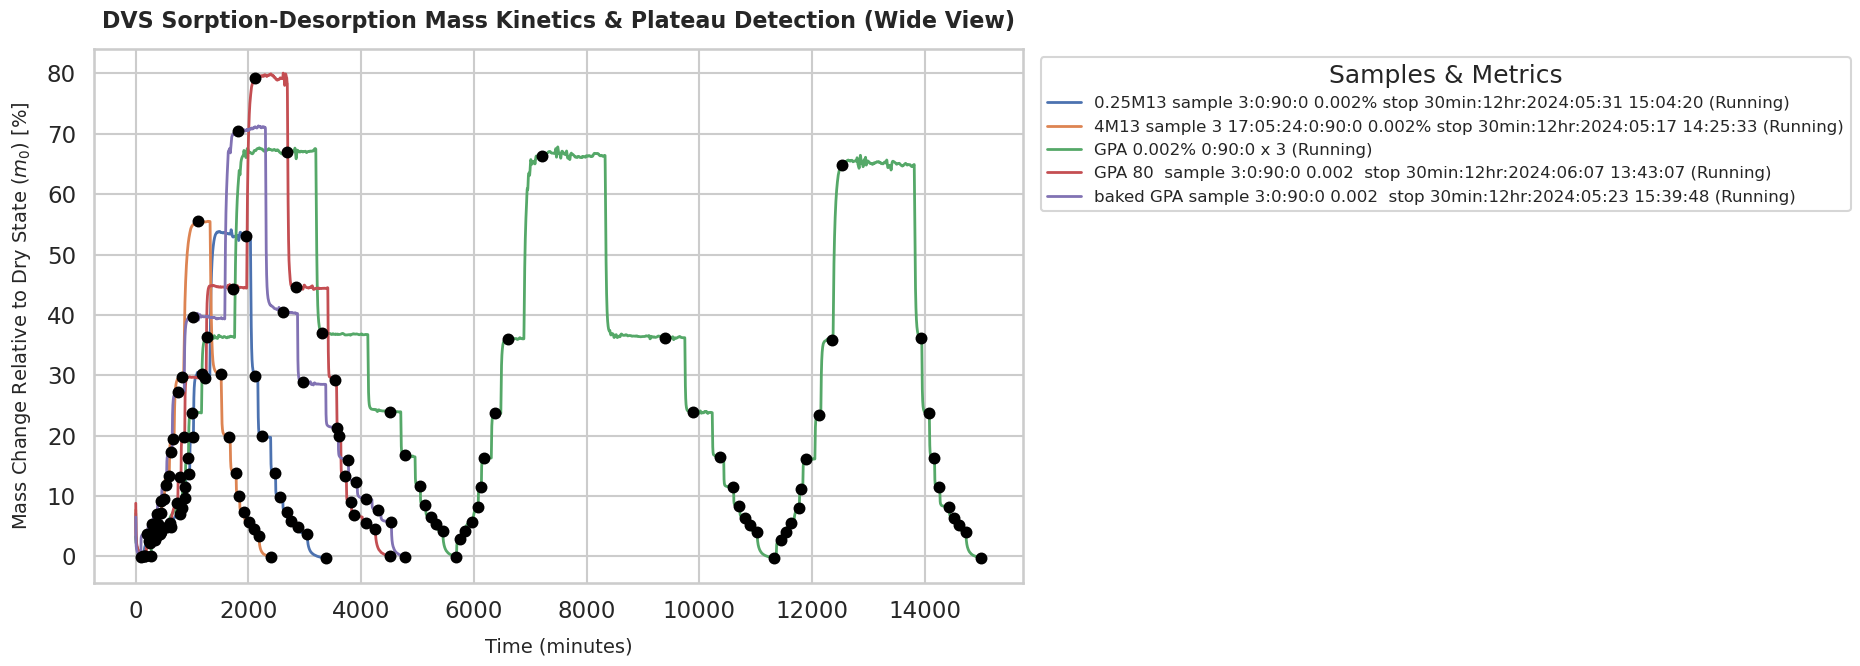

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 6: Visualize All Samples (Wide View) ---

# Set clean, professional plotting style
sns.set_theme(style="whitegrid", context="talk")

# INCREASED WIDTH: changed from (14, 8) to (19, 7) for a wider perspective
plt.figure(figsize=(19, 7))

# 1. Group by sample to overlay their individual runs
for sample_name, group in segmented_df.groupby('sample_name'):
    # Clean up the label for the legend
    clean_label = sample_name.split('_')[0] if '_' in sample_name else sample_name
    
    # Sort by time to ensure a continuous line plot
    plot_data = group.sort_values(by='time_minutes_')
    
    # 2. Plot the main kinetics curve (Time vs Running Mass Change)
    plt.plot(
        plot_data['time_minutes_'], 
        plot_data['mass_change_pct'], 
        label=f"{clean_label} (Running)", 
        linewidth=2
    )
    
    # 3. Highlight the extracted equilibrium points (flattest gradient markers)
    for stage_id, stage_data in plot_data.groupby('stage_id'):
        if not stage_data.empty:
            # Find where the running mass exactly equals the chosen equilibrium mass
            idx_closest = (stage_data['mass_mg_'] - stage_data['flat_equilibrium_mass']).abs().idxmin()
            
            plt.scatter(
                plot_data.loc[idx_closest, 'time_minutes_'],
                plot_data.loc[idx_closest, 'equilibrium_capacity_pct'],
                color='black',
                s=50,  # Slightly larger marker for the wide view
                zorder=5
            )

# Decorate the plot
plt.title("DVS Sorption-Desorption Mass Kinetics & Plateau Detection (Wide View)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Time (minutes)", fontsize=14, labelpad=10)
plt.ylabel("Mass Change Relative to Dry State ($m_0$) [%]", fontsize=14, labelpad=10)

# Position legend cleanly outside the wider chart area
plt.legend(title="Samples & Metrics", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=12)
plt.tight_layout()

# Show the visualization
plt.show()

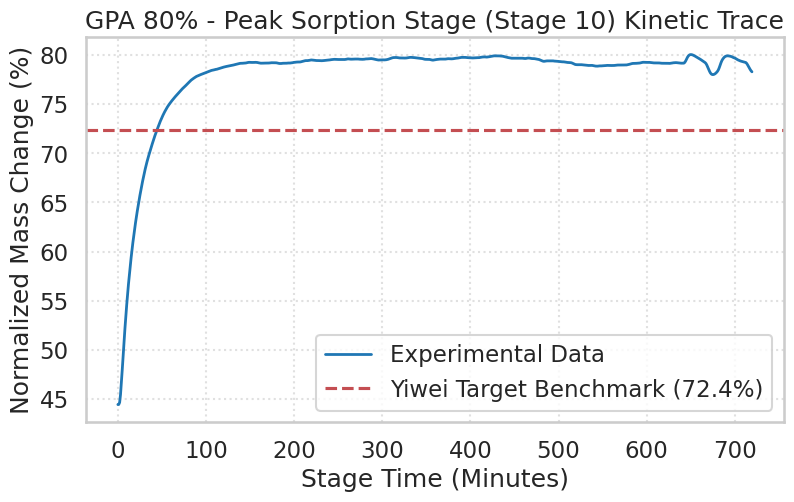

 Stage Total Duration: 719.4 minutes (~12.0 hours)
 Transient Peak Capacity: 80.04%
 Final Window Mass Value: 78.29%


In [7]:
import matplotlib.pyplot as plt

# --- Step 7: GPA 80% Peak-Stage Kinetic Trace ---

# 1. Isolate the GPA 80% sample
gpa_80 = segmented_df[segmented_df['sample_name'].str.contains('80', case=False)]

# 2. Isolate its peak sorption stage (usually the maximum stage_id or where target RH == 90%)
# Let's find the stage where it hits the absolute maximum mass_change_pct
peak_stage_id = gpa_80.loc[gpa_80['mass_change_pct'].idxmax(), 'stage_id']
peak_stage = gpa_80[gpa_80['stage_id'] == peak_stage_id].copy()

# Reset the stage clock to t=0 for clear kinetic viewing
peak_stage['stage_time'] = peak_stage['time_minutes_'] - peak_stage['time_minutes_'].iloc[0]

# 3. Plot the trace
plt.figure(figsize=(9, 5))
plt.plot(peak_stage['stage_time'], peak_stage['mass_change_pct'], color='#1f77b4', lw=2, label='Experimental Data')
plt.axhline(y=72.4, color='r', linestyle='--', label='Yiwei Target Benchmark (72.4%)')

# Annotate metrics
max_val = peak_stage['mass_change_pct'].max()
end_val = peak_stage['mass_change_pct'].iloc[-1]
total_duration = peak_stage['stage_time'].iloc[-1]

plt.title(f"GPA 80% - Peak Sorption Stage (Stage {peak_stage_id}) Kinetic Trace")
plt.xlabel("Stage Time (Minutes)")
plt.ylabel("Normalized Mass Change (%)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

print(f" Stage Total Duration: {total_duration:.1f} minutes (~{total_duration/60:.1f} hours)")
print(f" Transient Peak Capacity: {max_val:.2f}%")
print(f" Final Window Mass Value: {end_val:.2f}%")

In [19]:
# --- Step 8: Save Segmented Data to CSV ---
segmented_df.to_csv("segmented_dvs_data.csv", index=False)
print("✅ Data successfully saved to segmented_dvs_data.csv!")

✅ Data successfully saved to segmented_dvs_data.csv!
